# Chapter 01 Descriptive Statistics: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-01-descriptive-statistics-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for Chapter 1: Introduction to Descriptive Statistics.

Every function builds one self-contained, standalone Plotly HTML page and writes it
to ../_generated/. The matching chapter-01-descriptive-statistics.md file embeds each
page in an <iframe>, so the chapter never depends on a live Python kernel to render.

Run directly to regenerate every figure:
    python chapters/chapter-01-descriptive-statistics-plots.py

The running example throughout is a simulated API latency dataset. It is a synthetic
log-normal distribution built to have the same shape (right-skewed, long tail) that
production latency logs almost always have, chosen specifically because "mean vs.
median" is a decision engineers make every time they set an alert threshold. It is
labeled as simulated everywhere it appears; it is not a claim about any company's
production traffic.
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(42)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def simulated_latency_ms(n: int = 5000, contamination: float = 0.0) -> np.ndarray:
    """Log-normal 'normal traffic' latency, optionally contaminated with a slow tail
    (e.g. a scheduled batch job or a cold-start burst hitting the same endpoint)."""
    base = RNG.lognormal(mean=np.log(45), sigma=0.35, size=n)
    n_slow = int(n * contamination)
    if n_slow:
        slow = RNG.lognormal(mean=np.log(600), sigma=0.5, size=n_slow)
        base = np.concatenate([base[: n - n_slow], slow])
    return base


In [4]:


# ---------------------------------------------------------------------------
# Figure 1: mean vs. median as the slow-request contamination fraction rises
# ---------------------------------------------------------------------------
def fig_mean_vs_median() -> go.Figure:
    fractions = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20]
    frames = []
    for frac in fractions:
        data = simulated_latency_ms(contamination=frac)
        mean_v, median_v = float(np.mean(data)), float(np.median(data))
        hist = np.histogram(data, bins=np.linspace(0, 1200, 80))
        frames.append(
            go.Frame(
                name=f"{frac:.0%}",
                data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#4C78A8")],
                layout=go.Layout(
                    shapes=[
                        dict(type="line", x0=mean_v, x1=mean_v, y0=0, y1=1,
                             yref="paper", line=dict(color="#E45756", width=2, dash="solid")),
                        dict(type="line", x0=median_v, x1=median_v, y0=0, y1=1,
                             yref="paper", line=dict(color="#54A24B", width=2, dash="solid")),
                    ],
                    annotations=[
                        dict(x=mean_v, y=0.97, yref="paper", showarrow=False,
                             xanchor="left", text=f"mean = {mean_v:.0f} ms",
                             font=dict(color="#E45756")),
                        dict(x=median_v, y=0.88, yref="paper", showarrow=False,
                             xanchor="right", text=f"median = {median_v:.0f} ms",
                             font=dict(color="#54A24B")),
                    ],
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Simulated API latency: mean vs. median as slow requests creep in",
        xaxis_title="Latency (ms)",
        yaxis_title="Requests",
        xaxis_range=[0, 1200],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Slow-request share: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 2: std-dev alert threshold vs. percentile alert threshold
# ---------------------------------------------------------------------------
def fig_std_vs_percentile() -> go.Figure:
    data = simulated_latency_ms(contamination=0.02)
    mean_v, std_v = float(np.mean(data)), float(np.std(data))
    k_values = [1, 2, 3, 4]
    frames = []
    hist = np.histogram(data, bins=np.linspace(0, 1200, 80))
    p90, p99 = np.percentile(data, [90, 99])
    for k in k_values:
        threshold = mean_v + k * std_v
        frames.append(
            go.Frame(
                name=str(k),
                layout=go.Layout(
                    shapes=[
                        dict(type="line", x0=threshold, x1=threshold, y0=0, y1=1,
                             yref="paper", line=dict(color="#E45756", width=2)),
                        dict(type="line", x0=p90, x1=p90, y0=0, y1=1,
                             yref="paper", line=dict(color="#54A24B", width=2, dash="dot")),
                        dict(type="line", x0=p99, x1=p99, y0=0, y1=1,
                             yref="paper", line=dict(color="#F58518", width=2, dash="dot")),
                    ],
                    annotations=[
                        dict(x=0.02, y=0.97, xref="paper", yref="paper", showarrow=False,
                             xanchor="left",
                             text=f"mean + {k}×std = {threshold:.0f} ms",
                             font=dict(color="#E45756")),
                        dict(x=0.02, y=0.90, xref="paper", yref="paper", showarrow=False,
                             xanchor="left",
                             text=f"p90 = {p90:.0f} ms", font=dict(color="#54A24B")),
                        dict(x=0.02, y=0.83, xref="paper", yref="paper", showarrow=False,
                             xanchor="left",
                             text=f"p99 = {p99:.0f} ms", font=dict(color="#F58518")),
                    ],
                ),
            )
        )

    fig = go.Figure(
        data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#B7C7DB")],
        frames=frames,
        layout=frames[0].layout,
    )
    fig.update_layout(
        title="An alert threshold built from std. dev. moves with k; p90/p99 do not",
        xaxis_title="Latency (ms)",
        yaxis_title="Requests",
        xaxis_range=[0, 1200],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "k (std. deviations above the mean): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 3: covariance and correlation between payload size and latency
# ---------------------------------------------------------------------------
def fig_covariance_correlation() -> go.Figure:
    rhos = [0.0, 0.3, 0.6, 0.85]
    frames = []
    n = 400
    for rho in rhos:
        cov = [[1, rho], [rho, 1]]
        z = RNG.multivariate_normal([0, 0], cov, size=n)
        payload_kb = 2 + 18 * stats.norm.cdf(z[:, 0])
        latency_ms = 40 + 260 * stats.norm.cdf(z[:, 1])
        r, _ = stats.pearsonr(payload_kb, latency_ms)
        frames.append(
            go.Frame(
                name=f"{rho:.2f}",
                data=[go.Scatter(x=payload_kb, y=latency_ms, mode="markers",
                                  marker=dict(color="#4C78A8", size=6, opacity=0.55))],
                layout=go.Layout(
                    annotations=[dict(
                        x=0.02, y=0.98, xref="paper", yref="paper", showarrow=False,
                        text=f"sample Pearson r = {r:.2f}", align="left",
                        font=dict(size=13, color="#333"),
                    )]
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Payload size vs. response latency, simulated at increasing correlation",
        xaxis_title="Request payload size (KB)",
        yaxis_title="Latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "underlying correlation ρ: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 4: skewness and kurtosis as the distribution shape changes
# ---------------------------------------------------------------------------
def fig_skewness_kurtosis() -> go.Figure:
    sigmas = [0.05, 0.2, 0.4, 0.6, 0.9]
    frames = []
    for sigma in sigmas:
        data = RNG.lognormal(mean=0, sigma=sigma, size=8000)
        skew = float(stats.skew(data))
        kurt = float(stats.kurtosis(data))  # excess kurtosis, normal = 0
        hist = np.histogram(data, bins=60, range=(0, 6))
        frames.append(
            go.Frame(
                name=f"{sigma:.2f}",
                data=[go.Bar(x=hist[1][:-1], y=hist[0], marker_color="#72B7B2")],
                layout=go.Layout(
                    annotations=[dict(
                        x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                        xanchor="right", align="right",
                        text=f"skewness = {skew:.2f}<br>excess kurtosis = {kurt:.2f}",
                        font=dict(size=13, color="#333"),
                    )]
                ),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="From near-symmetric to heavy-tailed: watch skewness and kurtosis move",
        xaxis_title="Simulated value",
        yaxis_title="Count",
        xaxis_range=[0, 6],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "log-normal σ (shape parameter): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 5: Simpson's paradox, the Charig et al. (1986) kidney stone data
# ---------------------------------------------------------------------------
def fig_simpsons_paradox_kidney_stones() -> go.Figure:
    # Source: Charig CR, Webb DR, Payne SR, Wickham JEA. "Comparison of treatment
    # of renal calculi by open surgery, percutaneous nephrolithotomy, and
    # extracorporeal shockwave lithotripsy." BMJ 1986;292:879-882.
    #
    # x-axis positions and tick labels are set once at the layout level (below) and
    # never re-derived from trace category strings, since Plotly does not reliably
    # redraw categorical tick text when a frame changes the number of bars. A
    # single trace covers every frame (four bars for "by stone size", two for
    # "combined"), which also sidesteps a separate bug where a two-trace-per-frame
    # version loaded the wrong initial data on first render.
    small = dict(rate_a=81 / 87 * 100, rate_b=234 / 270 * 100)
    large = dict(rate_a=192 / 263 * 100, rate_b=55 / 80 * 100)
    combined = dict(rate_a=273 / 350 * 100, rate_b=289 / 350 * 100)

    grouped_x = [-0.2, 0.2, 0.8, 1.2]
    grouped_y = [small["rate_a"], large["rate_a"], small["rate_b"], large["rate_b"]]
    grouped_colors = ["#4C78A8", "#A6C6E3", "#F58518", "#FDBF7A"]
    grouped_text = [f"{v:.0f}%" for v in grouped_y]

    combined_x = [0, 1]
    combined_y = [combined["rate_a"], combined["rate_b"]]
    combined_colors = ["#4C78A8", "#F58518"]
    combined_text = [f"{v:.0f}%" for v in combined_y]

    grouped_annotations = [
        dict(x=-0.2, y=small["rate_a"] + 8, text="Small", showarrow=False,
             font=dict(size=10, color="#555")),
        dict(x=0.2, y=large["rate_a"] + 8, text="Large", showarrow=False,
             font=dict(size=10, color="#555")),
        dict(x=0.8, y=small["rate_b"] + 8, text="Small", showarrow=False,
             font=dict(size=10, color="#555")),
        dict(x=1.2, y=large["rate_b"] + 8, text="Large", showarrow=False,
             font=dict(size=10, color="#555")),
    ]

    frames = [
        go.Frame(name="By stone size", data=[go.Bar(
            x=grouped_x, y=grouped_y, marker_color=grouped_colors, width=0.35,
            text=grouped_text, textposition="outside")],
            layout=go.Layout(annotations=grouped_annotations)),
        go.Frame(name="Combined", data=[go.Bar(
            x=combined_x, y=combined_y, marker_color=combined_colors, width=0.5,
            text=combined_text, textposition="outside")],
            layout=go.Layout(annotations=[])),
    ]

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Kidney stone treatment success rate: split by stone size vs. combined"
              "<br><sup>Data: Charig et al. 1986, BMJ 292:879-882</sup>",
        yaxis_title="Success rate (%)",
        yaxis_range=[0, 112],
        xaxis=dict(tickvals=[0, 1], ticktext=["Treatment A", "Treatment B"], range=[-0.6, 1.6]),
        annotations=grouped_annotations,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "View: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 400}}]}
                for f in frames
            ],
        }],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 6: mean imputation flattens variance as the missing share grows
# ---------------------------------------------------------------------------
def fig_mean_imputation() -> go.Figure:
    full = simulated_latency_ms(n=2000, contamination=0.03)
    missing_shares = [0.0, 0.1, 0.25, 0.4, 0.6]
    frames = []
    for share in missing_shares:
        mask = RNG.random(full.shape[0]) < share
        observed = full[~mask]
        imputed = full.copy()
        imputed[mask] = observed.mean() if observed.size else full.mean()
        frames.append(
            go.Frame(
                name=f"{share:.0%}",
                data=[
                    go.Histogram(x=full, name="Original (no missing)", opacity=0.55,
                                  marker_color="#B7C7DB", nbinsx=60),
                    go.Histogram(x=imputed, name="After mean imputation", opacity=0.55,
                                  marker_color="#E45756", nbinsx=60),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"original std = {full.std():.0f} ms<br>"
                          f"after imputation std = {imputed.std():.0f} ms"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="overlay",
        title="Mean imputation quietly shrinks the spread as more values go missing",
        xaxis_title="Latency (ms)",
        yaxis_title="Requests",
        xaxis_range=[0, 1200],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Share of values missing: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [10]:


# ---------------------------------------------------------------------------
# Figure 7: Literary Digest 1936, predicted vote share vs. the election result
# ---------------------------------------------------------------------------
def fig_literary_digest_predicted_vs_actual() -> go.Figure:
    # Source: Squire, P. (1988). "Why the 1936 Literary Digest Poll Failed."
    # Public Opinion Quarterly 52(1):125-133. Landon predicted 57%, Roosevelt won
    # with almost 61% of the popular vote (60.8%); remainder to third-party
    # candidates in both rows.
    # Bar x-labels are held identical across both frames on purpose: Plotly does not
    # reliably redraw categorical axis tick text on frame animation, only the bar
    # heights, so changing the label text here would leave stale text on screen.
    # The slider's own "View:" caption (below) distinguishes the two states instead.
    predicted = dict(
        labels=["Landon", "Roosevelt"],
        values=[57.0, 43.0],
        colors=["#F58518", "#4C78A8"],
    )
    outcome = dict(
        labels=["Landon", "Roosevelt"],
        values=[36.5, 60.8],
        colors=["#F58518", "#4C78A8"],
    )

    frames = [
        go.Frame(name="Literary Digest prediction", data=[go.Bar(
            x=predicted["labels"], y=predicted["values"], marker_color=predicted["colors"],
            text=[f"{v:.0f}%" for v in predicted["values"]], textposition="outside")]),
        go.Frame(name="Election result", data=[go.Bar(
            x=outcome["labels"], y=outcome["values"], marker_color=outcome["colors"],
            text=[f"{v:.1f}%" for v in outcome["values"]], textposition="outside")]),
    ]

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="The 1936 Literary Digest poll: a confident prediction, a landslide the "
              "other way"
              "<br><sup>Data: Squire 1988, Public Opinion Quarterly 52(1):125-133</sup>",
        yaxis_title="Share of popular vote (%)",
        yaxis_range=[0, 70],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "View: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 400}}]}
                for f in frames
            ],
        }],
        margin=dict(t=90, l=60, r=30, b=50),
    )
    return fig


In [11]:


FIGURES = {
    "chapter-01-fig-mean-vs-median": fig_mean_vs_median,
    "chapter-01-fig-std-vs-percentile": fig_std_vs_percentile,
    "chapter-01-fig-covariance-correlation": fig_covariance_correlation,
    "chapter-01-fig-skewness-kurtosis": fig_skewness_kurtosis,
    "chapter-01-fig-simpsons-paradox": fig_simpsons_paradox_kidney_stones,
    "chapter-01-fig-mean-imputation": fig_mean_imputation,
    "chapter-01-fig-literary-digest": fig_literary_digest_predicted_vs_actual,
}


**`chapter-01-fig-mean-vs-median`**

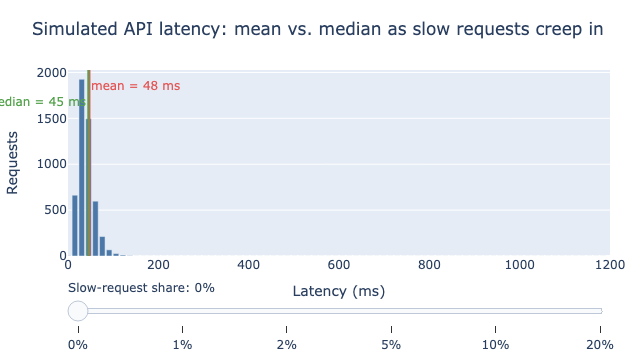

In [12]:
fig = FIGURES["chapter-01-fig-mean-vs-median"]()
fig

**`chapter-01-fig-std-vs-percentile`**

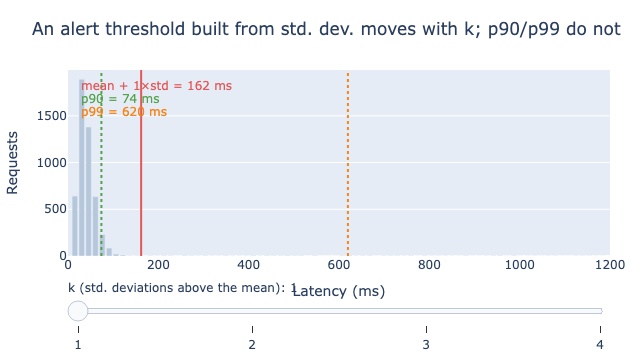

In [13]:
fig = FIGURES["chapter-01-fig-std-vs-percentile"]()
fig

**`chapter-01-fig-covariance-correlation`**

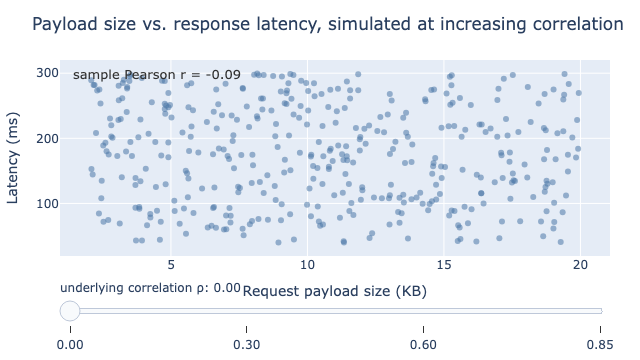

In [14]:
fig = FIGURES["chapter-01-fig-covariance-correlation"]()
fig

**`chapter-01-fig-skewness-kurtosis`**

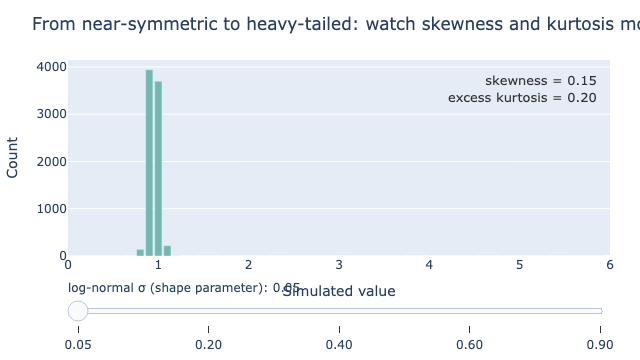

In [15]:
fig = FIGURES["chapter-01-fig-skewness-kurtosis"]()
fig

**`chapter-01-fig-simpsons-paradox`**

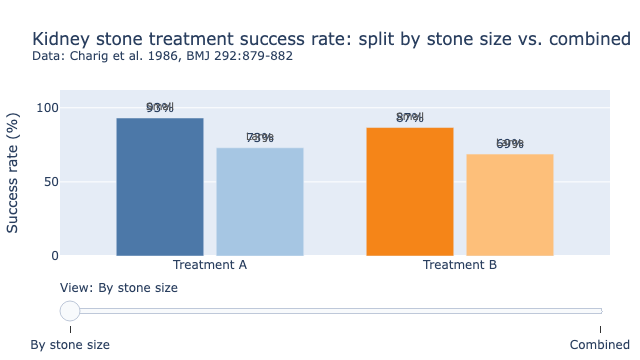

In [16]:
fig = FIGURES["chapter-01-fig-simpsons-paradox"]()
fig

**`chapter-01-fig-mean-imputation`**

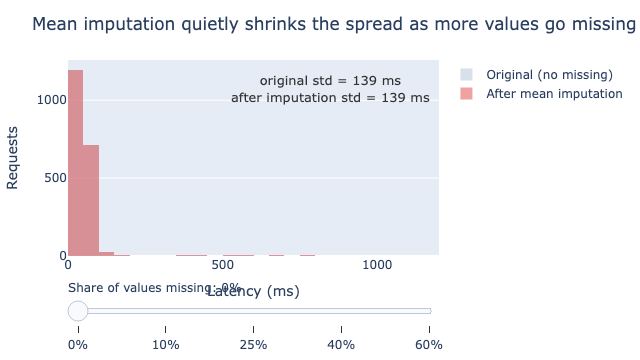

In [17]:
fig = FIGURES["chapter-01-fig-mean-imputation"]()
fig

**`chapter-01-fig-literary-digest`**

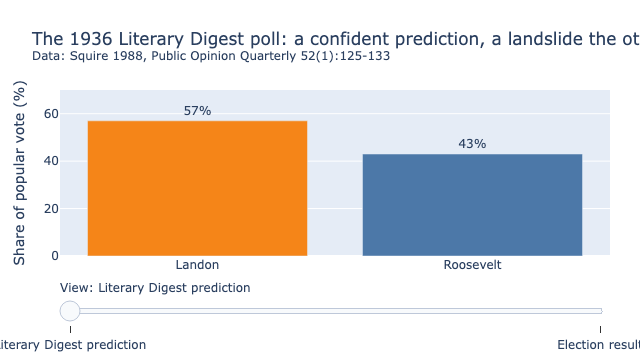

In [18]:
fig = FIGURES["chapter-01-fig-literary-digest"]()
fig